In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Loading Data

In [2]:
df = pd.read_pickle("data/df_train.pkl")

df_train, df_val = train_test_split(df, test_size= 0.1, random_state=42)

In [3]:
X_train = df_train.business_description_embedding.apply(ast.literal_eval).tolist()
X_train = np.array(X_train)
X_val = df_val.business_description_embedding.apply(ast.literal_eval).tolist()
X_val = np.array(X_val)

In [4]:
df_train.head(3)

,id,industry,business_description_embedding
31138,34170,Financial Services,"[0.019633012,0.009427597,0.006240986,0.0177257..."
15120,16504,Technology Hardware & Equipment,"[0.026561439,-0.049749356,-0.006847293,-0.0088..."
23693,25893,Consumer Durables & Apparel,"[0.0115894,-0.035240766,-0.029952582,0.0226988..."


# Transforming Data (Label Encoding)

### Tasks:
- Use the scikit-learn label encoder to encode the industry names
- Check if all classes contained in the validation set are also in the training set

In [5]:
# use the scikit-leanr label encoder to encode the industry names
le = LabelEncoder()
y_train = le.fit_transform(df_train['industry'])
y_val = le.transform(df_val['industry'])

# store the unencoded class/industry names in separate variables
train_classes = set(df_train['industry'])
val_classes = set(df_val['industry'])

# check if all classes contained in the validation set are also in the training set
missing_classes = val_classes - train_classes
if len(missing_classes) == 0:
    print("All classes contained in the validation set are also in the training set.")
else:
    print("The following classes are missing in the training set:", missing_classes)

All classes contained in the validation set are also in the training set.


# Visualize the data
### Tasks:
- Are certain classes over- or under represented? Either produce a table or a plot to show this.
- Inspect whether there is signal in the business description embeddings:
    - Perform a PCA to project data into 2 dimensions
    - Plot projected data in Scatterplot and color based on classes
    - Provide a description of what you see and judge whether there is signal in the data that allows industry classification

Important: Ensure that your plots have proper axis descriptions and titles. Style the plots so that differences in class distributions are visible (e.g. scatter size, transparency, color, etc.)

### Class distribution

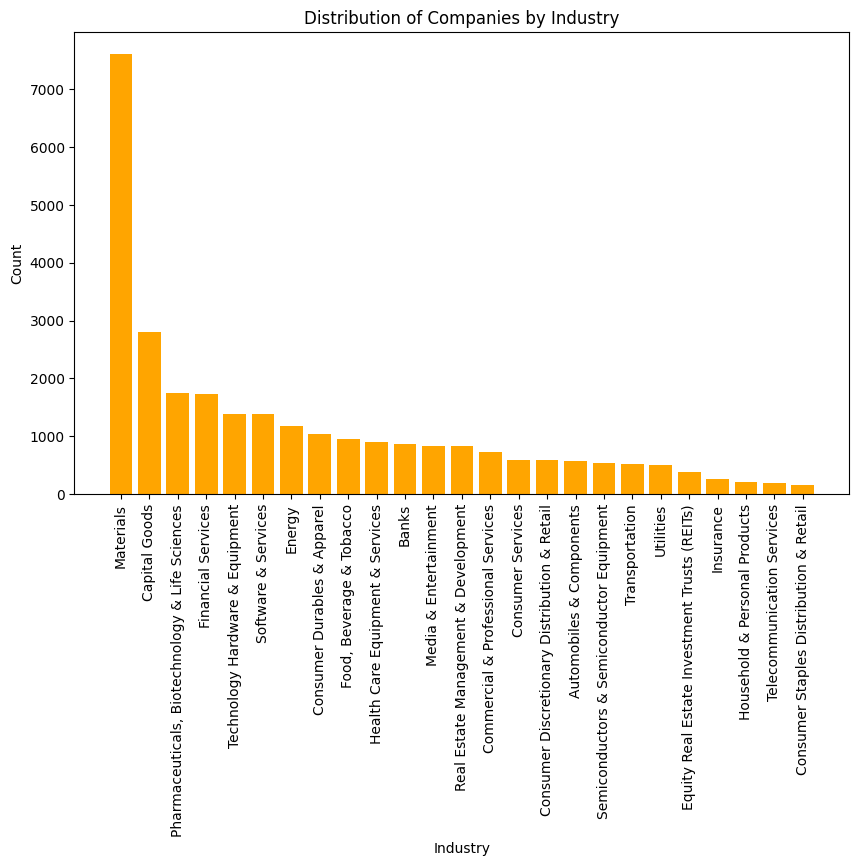

In [6]:
# to see whether certain classes are over- or under represented we produce a plot (using only the training data from now on)
industry_counts = df_train['industry'].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(industry_counts.index, industry_counts.values, color='orange')
plt.xlabel('Industry')
plt.ylabel('Count')
plt.title('Distribution of Companies by Industry')
plt.xticks(rotation=90)
plt.show()

### Describe your findings

From the plot, we clearly see that the distribution of samples across different industries is quite uneven. For instance, the "Materials" industry has a noticeably high number of samples, exceeding 7'000. Some other industries, such as "Consumer Staples Distribution & Retail", have fewer than 200 samples. This highlights a considerable imbalance in the dataset, suggesting that certain industries are fairly over-represented while a few others are under-represented.

### PCA - Dimensionality reduction and visualization

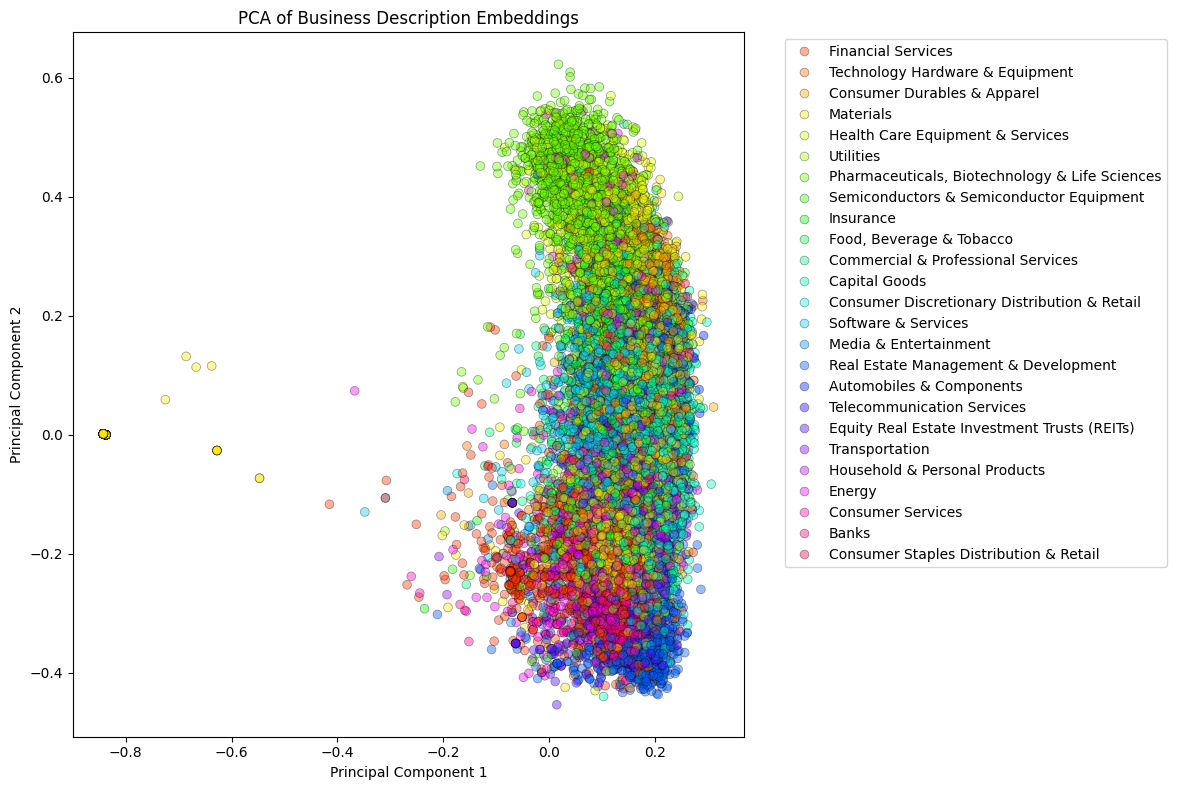

In [7]:
# perform a PCA to project data into 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train)

# store the results in a data frame which makjes it easier to plot
df_pca = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Industry': le.inverse_transform(y_train)})

# plot projected data in Scatterplot and color based on classes
plt.figure(figsize=(12, 8))
num_classes= len(df_pca['Industry'].unique())
sns.scatterplot(
    data=df_pca,
    x='PC1', y='PC2',
    hue='Industry',
    palette=sns.color_palette("hsv", n_colors=num_classes),
    s=40,
    alpha=0.4,
    edgecolor='k')
plt.title('PCA of Business Description Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Analyse what you see

From the PCA plot, we see that some industries, such as "Pharmaceuticals, Biotechnology & Life Sciences", and "Real Estate Management & Development", form relatively distinct clusters. This suggests that companies in these sectors share similar characteristics based on the underlying features. In contrast, other sectors appear more spread out and overlap with each other, indicating less separation along the first two principal components. This means that the PCA does not clearly distinguish all industries, possibly because some sectors have similar feature patterns. Overall, there seems to be some signal in the data that can help classify industries, but it is not consistent across all categories.

# Fitting and comparing Classifier Models

### Tasks:
- Split the data into train and validation data
- Encode the industry labels using LabelEncoder (scikit-learn)
- Fit a LogisticRegression and a kNN-classifier
- Compare the model performance of both models:
    - Compute Accuracy and F1 score
        - Interpret the scores: Explain how they are computed and judge if your model performs well
        - Analyze the classification errors: 
            - Do the errors correlate with how well classes are represented?
            - Which industries does the model identify well and which seem to be similar?
    - Plot a confusion matrix for both models (combine scikit-learn confusion matrix and seaborn heatmap plot)
    - Do both models misclassify the same examples?

Import: Use proper axis labels for the plots! 

In [8]:
# logistic regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_val)

# compute accuracy and F1 score
acc_log = accuracy_score(y_val, y_pred_log)
f1_log = f1_score(y_val, y_pred_log, average='weighted')

print(f" Logistic Regression:")
print(f"  Accuracy: {acc_log:.4f}")
print(f"  F1-score (weighted): {f1_log:.4f}")


# kNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_val)

# also compute the accuracy and F1 score here to compare
acc_knn = accuracy_score(y_val, y_pred_knn)
f1_knn = f1_score(y_val, y_pred_knn, average='weighted')

print(f"\n kNN Classifier:")
print(f"  Accuracy: {acc_knn:.4f}")
print(f"  F1-score (weighted): {f1_knn:.4f}")

 Logistic Regression:
  Accuracy: 0.7720
  F1-score (weighted): 0.7663

 kNN Classifier:
  Accuracy: 0.7531
  F1-score (weighted): 0.7495


### Interpretation of accuracy and F1 score

(Question: Interpret the scores: Explain how they are computed and judge if your model performs well)

Accuracy measures the proportion of all predictions that are correct: $$Accuracy = \dfrac{\text{Number of correct predictions}}{\text{Total number of predictions}}$$

It provides an overall measure of model correctness.


F1-score is the harmonic mean of precision and recall: $$
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

The weighted F1-score averages the F1 of each class according to its support (number of samples per class), which makes it suitable for imbalanced datasets.


Both models perform fairly well and we see that Logistic Regression does slightly better than kNN. For Logistic Regresson, an accuracy of around 77% and a weighted F1-score of 0.766 show that the business description embeddings contain useful information about the company’s industry. The Logistic Regression model seems to generalize well across different classes, while the slightly lower performance of kNN is expected due to the high-dimensional nature of the embeddings. Overall, the results suggest that the embeddings are effective and provide useful information for industry classification.

In [9]:
# classification errors of the logistic regression
print("Logistic Regression Classification Report")
print(classification_report(y_val, y_pred_log, target_names=le.classes_))

# classification errors of the kNN classifier
print("kNN Classification Report")
print(classification_report(y_val, y_pred_knn, target_names=le.classes_))

Logistic Regression Classification Report
                                                precision    recall  f1-score   support

                      Automobiles & Components       0.70      0.66      0.68        53
                                         Banks       0.99      0.92      0.95        74
                                 Capital Goods       0.66      0.75      0.70       322
            Commercial & Professional Services       0.54      0.35      0.42        78
  Consumer Discretionary Distribution & Retail       0.61      0.55      0.58        67
                   Consumer Durables & Apparel       0.69      0.58      0.63       127
                             Consumer Services       0.76      0.69      0.72        81
        Consumer Staples Distribution & Retail       0.33      0.05      0.09        20
                                        Energy       0.84      0.55      0.67       152
  Equity Real Estate Investment Trusts (REITs)       0.84      0.82      0.83

### Analysis 1/3

Question: Analyze the classification errors: Do the errors correlate with how well classes are represented?

After reviewing the classification reports for both models, we can see that the F1 scores vary quite a lot across different industries. Well-represented industries, such as "Materials", have higher F1 scores, meaning the models can identify and classify companies in these categories more accurately. On the other hand, under-represented industries, like "Consumer Staples Distribution & Retail", have much lower F1 scores, showing that the models struggle to classify them correctly. This suggests that there is imbalance in the dataset which affects model performance. Industries with more samples provide the model with more information which helps in accurate prediction, while the models find it difficult to predict accurately for industries with fewer samples.

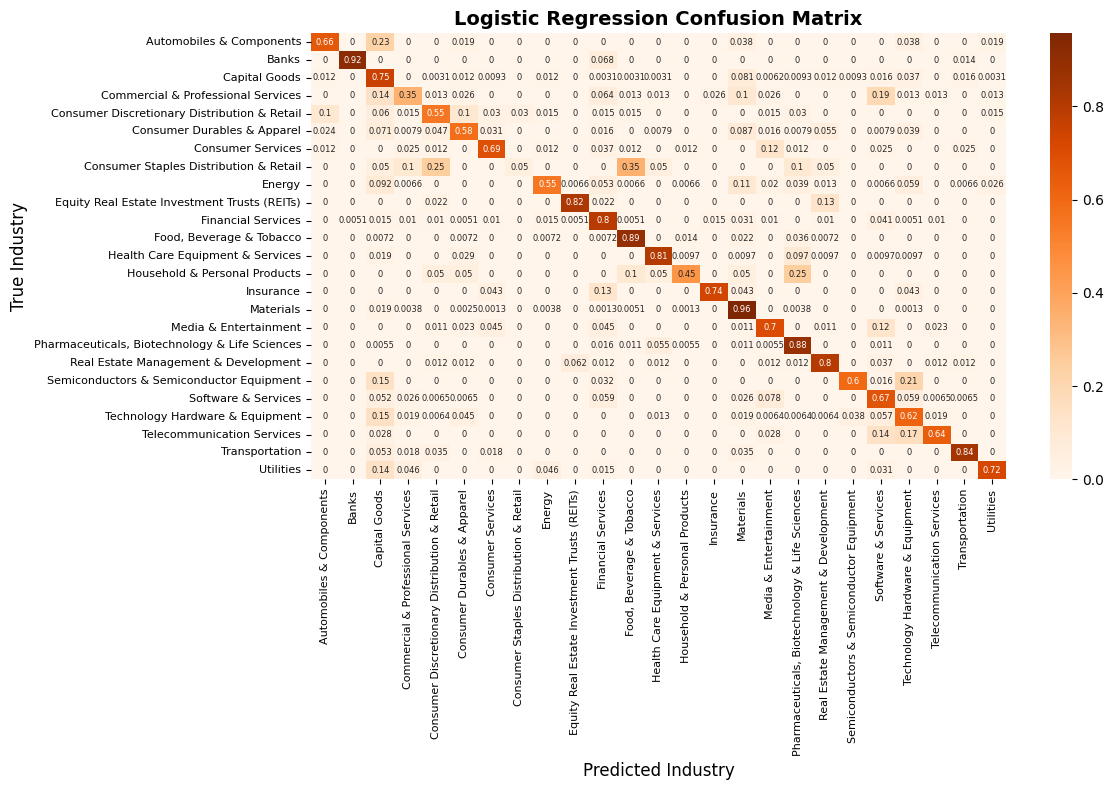

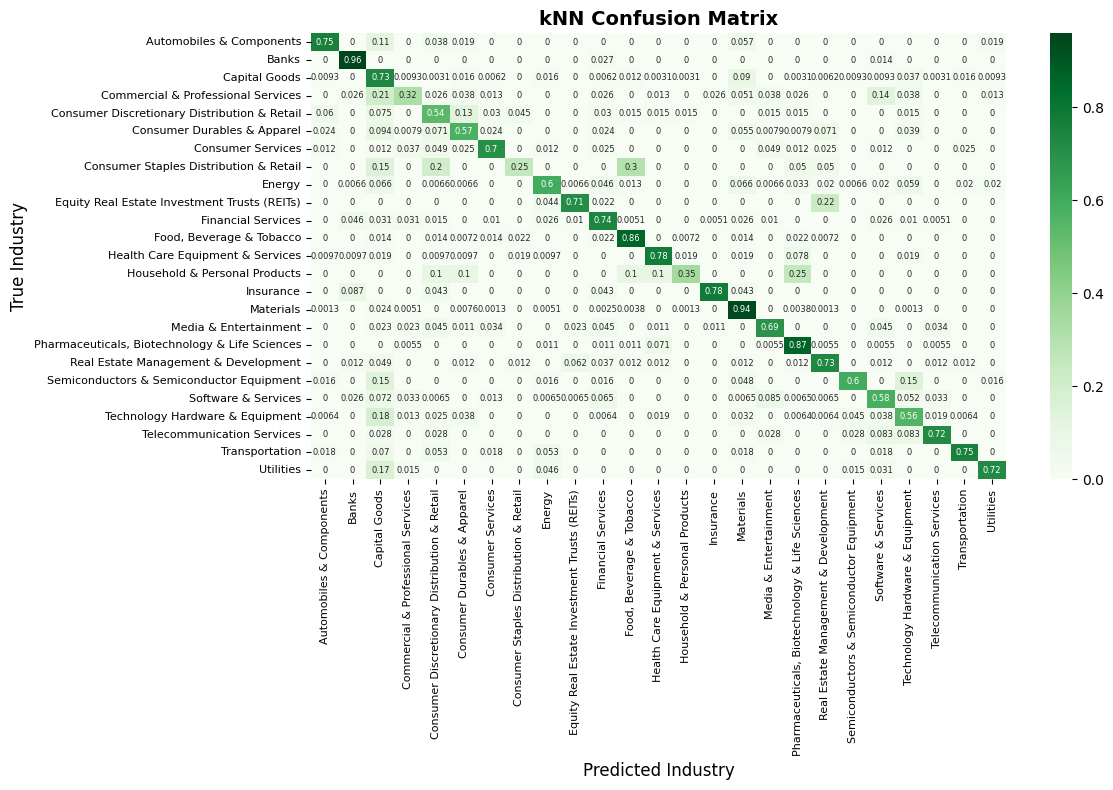

In [10]:
# plot a confusion matrix for both models (combine scikit-learn confusion matrix and seaborn heatmap plot)
cm_log = confusion_matrix(y_val, y_pred_log, normalize='true')
cm_knn = confusion_matrix(y_val, y_pred_knn, normalize='true')

# logistic regression
plt.figure(figsize=(12, 8))
sns.heatmap(cm_log, cmap='Oranges', annot=True, annot_kws={'size': 6})
plt.title("Logistic Regression Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Industry", fontsize=12)
plt.ylabel("True Industry", fontsize=12)
plt.xticks(ticks=np.arange(len(le.classes_)) + 0.5, labels=le.classes_, rotation=90, fontsize=8)
plt.yticks(ticks=np.arange(len(le.classes_)) + 0.5, labels=le.classes_, rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# kNN
plt.figure(figsize=(12, 8))
sns.heatmap(cm_knn, cmap='Greens', annot=True, annot_kws={'size': 6})
plt.title("kNN Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Industry", fontsize=12)
plt.ylabel("True Industry", fontsize=12)
plt.xticks(ticks=np.arange(len(le.classes_)) + 0.5, labels=le.classes_, rotation=90, fontsize=8)
plt.yticks(ticks=np.arange(len(le.classes_)) + 0.5, labels=le.classes_, rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

### Analysis 2/3

Question: Which industries does the model identify well and which seem to be similar?

Both models perform quite well in identifying industries such as "Banks", "Financial Services", "Insurance", "Food, Beverage & Tobacco", and "Pharmaceuticals, Biotechnology & Life Sciences". These industries tend to have more distinct characteristics, which makes it easier for the models to recognize and classify them correctly.

However, sectors like "Consumer Discretionary Distribution & Retail", "Consumer Services", "Consumer Durables & Apparel", and "Commercial & Professional Services" show more overlap and confusion. The companies in these sectors mostly have similar business descriptions or features, which makes it harder for the models to distinguish between them. As a result, the models are more likely to misclassify companies in these categories.

This suggests that some industries have clear patterns in their data, while others are require additional information or more advanced models to achieve better classification accuracy.

In [11]:
# see wehther both our models misclassified the same samples
misclassified_log = (y_val != y_pred_log)
misclassified_knn = (y_val != y_pred_knn)

same_misclassified = np.sum(misclassified_log & misclassified_knn)
total_misclassified = np.sum(misclassified_log | misclassified_knn)

print(f"Both models misclassified the same {same_misclassified} samples.")
print(f"That is {same_misclassified / total_misclassified: .2%} of all misclassifications.")

Both models misclassified the same 535 samples.
That is  55.10% of all misclassifications.


### Analysis 3/3

Question: Do both models misclassify the same examples?

Both models misclassify many of the same samples. Specifically, 55.1% of all misclassifications are shared between Logistic Regression and kNN. This indicates that both models struggle with similar examples, such as industries with overlapping descriptions. While there are differences in the total number of misclassifications for each model, the majority of errors occur on the same difficult samples. This shows that both models are affected by inherent ambiguity in the embeddings for certain industries.

# Optional: Confidence Weighted Prediction

## Deliverables:

- Provide a notebook with the implementation and training of a industry classifier model
- The model shall output the industry classification and its confidence as a tuple of vectors $(\hat{y}_{pred}, \hat{y}_{confidence})$
- The confidence score must be between 0 and 1, $\hat{y}_{confidence} [i] \in [0,1]$
- Your model will be evaluated on a private test set
- The designing the confidence score is your task. You may use p-values, a voting mechanism of multiple models, or other techniques
- Another option is to add more features, e.g. financial data, to X

In [12]:
def confidence_weighted_f1(y_true, y_pred, confidence):
    # Weight all predictions, not just positives
    weighted_tp = np.sum(confidence * (y_pred == 1) * (y_true == 1))
    weighted_fp = np.sum(confidence * (y_pred == 1) * (y_true == 0))
    weighted_fn = np.sum(confidence * (y_pred == 0) * (y_true == 1))
    
    precision = weighted_tp / (weighted_tp + weighted_fp) if (weighted_tp + weighted_fp) > 0 else 0
    recall = weighted_tp / (weighted_tp + weighted_fn) if (weighted_tp + weighted_fn) > 0 else 0
    
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return f1